In [15]:
import os

os.environ["SYCL_BE"] = "PI_OPENCL"                 
os.environ["ONEAPI_DEVICE_SELECTOR"] = "opencl:gpu"
os.environ["ZES_ENABLE_SYSMAN"] = "1"
os.environ["SYCL_PI_LEVEL_ZERO_USE_COPY_ENGINE"] = "0"


import torch
import numpy as np
import smplotlib
import matplotlib.pyplot as plt
import scipy
import flan_sigw
cmap = plt.get_cmap('tab10')

In [16]:
plt.rcParams.update({
    'font.size': 14,
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'axes.linewidth': 1.2
})

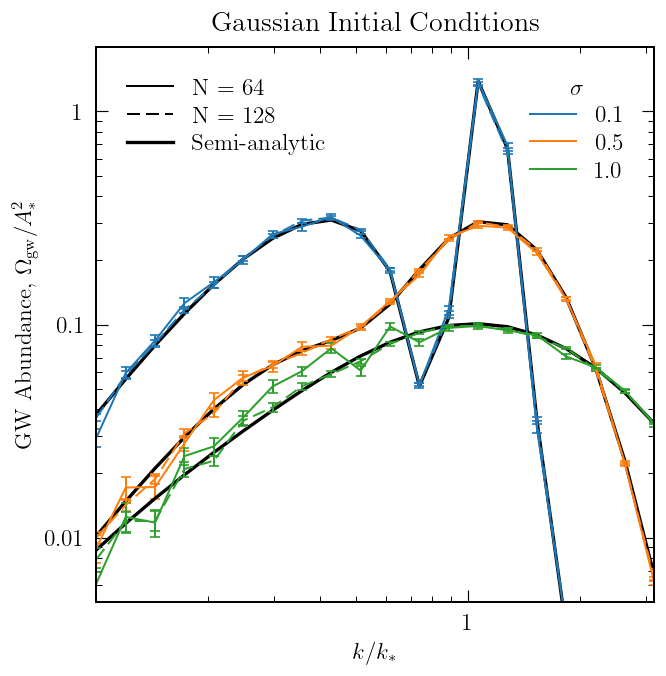

In [17]:
import math
import matplotlib.lines as mlines
cmap = plt.get_cmap('tab10')
A_star = 1e-2
k_star = 1

N_tot = 100
device = torch.device("cuda")
u, w = flan_sigw.create_smooth_density_grid(u_min=1e-3, u_max=15.0, N_modes=N_tot, u_pivot=1, sigma=0.5, amplitude=10.0, device=device)

#build_Omega_gw is a function factory; its output is a callable function, Omega_gw(k, Phi_i, L, N_modes)
#where k is the wanted value at which compute Omega_gw, Phi_i is the box of initial conditions, L the side of the box, 
#N_modes = (N_s, N_c) the number of modes included in the reconstruction
Omega_gw_1 = flan_sigw.build_Omega_gw(u, w, threshold = 0.9, Delta = 1)


N_s = 50
N_c = N_s
N_modes = N_s, N_c

k = 10**torch.linspace(-1, 0.5, 20, device=device)*k_star

eps = 0.1
k_ = k_star*10**torch.arange(-2, 2, 0.01)
sigma = [0.1, 0.5, 1]

for i in range(0, len(sigma)):
    N_low = 64
    O_gw = []
    sigma_O_gw = []

    Delta_zeta = flan_sigw.build_log_normal(A_star, k_star, sigma[i])
    plt.loglog(k.cpu(), flan_sigw.Omega_gw_semianalitic(k.cpu().numpy(), Delta_zeta)/A_star**2, color = 'black', linewidth = 2)
    y = Delta_zeta(k_.cpu().numpy())
    y = scipy.integrate.cumulative_trapezoid(y, np.log(k_.cpu().numpy()), initial=0)
    y = torch.tensor(y)
    k_bar = k_[torch.min(torch.argwhere(y/y[-1]>1- eps))]
    N = N_low
    for kk in k:    
        k_max = np.max([k_bar, 3.*kk.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_gaussian_field_k(N, L, Delta_zeta,  device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(kk, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)
    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='-', capsize=3)
    
    N_high = N_low*2
    O_gw = []
    sigma_O_gw = []

    Delta_zeta = flan_sigw.build_log_normal(A_star, k_star, sigma[i])
    y = Delta_zeta(k_.cpu().numpy())
    y = scipy.integrate.cumulative_trapezoid(y, np.log(k_.cpu().numpy()), initial=0)
    y = torch.tensor(y)
    k_bar = k_[torch.min(torch.argwhere(y/y[-1]>1- eps))]
    N = N_high
    for kk in k:    
        k_max =  np.max([k_bar, 3.*kk.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_gaussian_field_k(N, L, Delta_zeta,  device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(kk, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)
    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='--', capsize=3)
    
plt.yscale('log')
plt.xscale('log')
plt.ylabel('GW Abundance, $\Omega_{\\rm gw}/A_*^2$')
plt.xlabel('$k/k_*$')
plt.title(f'Gaussian Initial Conditions')
plt.vlines(k_bar, 0, 10, linewidth = 0.5, linestyles='--')
plt.vlines(k_bar, 0, 10, linewidth = 0.5, linestyles='--')
plt.xlim(k.cpu()[0], k.cpu()[-1])
plt.ylim(0.005, 2)



color_handles = [mlines.Line2D([], [], color=cmap(i), linestyle='-', label=f'{sigma[i]:.1f}') for i in range(len(sigma))]
first_legend = plt.legend(handles=color_handles, title='$\\sigma$', loc='upper right')
plt.gca().add_artist(first_legend) 

style_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', label=f'N = {N_low:.0f}'),
    mlines.Line2D([], [], color='black', linestyle='--', label=f'N = {N_high:.0f}'),
    mlines.Line2D([], [], color='black', linewidth = '2', linestyle='-', label=f'Semi-analytic')
]
plt.legend(handles=style_handles, loc='upper left') 
plt.savefig('plots/gaussian.pdf')

In [18]:


A_star = 1e-2
k_star = 1
sigma = 0.1
Delta_zeta = flan_sigw.build_log_normal(A_star, k_star, sigma)

k = 10**torch.linspace(-1, 0.5, 20, device=device)*k_star
eps = 0.1
k_ = k_star*10**torch.arange(-2, 2, 0.01)
y = Delta_zeta(k_)
y = scipy.integrate.cumulative_trapezoid(y, torch.log(k_), initial=0)
y = torch.tensor(y)
k_bar = k_[torch.min(torch.argwhere(y/y[-1]>1- eps))]

cmap = plt.get_cmap('tab10')#plt.get_cmap('inferno')


In [19]:
k_data = np.loadtxt('non_gaussian_data/GP_fNL2_LN_0.1.txt')[:, 0]
fNL2 = np.loadtxt('non_gaussian_data/GP_fNL2_LN_0.1.txt')[:, 1]
fNL4 = np.loadtxt('non_gaussian_data/GP_fNL4_LN_0.1.txt')[:, 1]
gNL = np.loadtxt('non_gaussian_data/GP_gNL_LN_0.1.txt')[:, 1]
gNL2 = np.loadtxt('non_gaussian_data/GP_gNL2_LN_0.1.txt')[:, 1]
gauss = np.loadtxt('non_gaussian_data/GP_Gaussian_LN_0.1.txt')[:, 1]

def Omega_gw_nongaussian(A_star, F_NL, G_NL): 
    return A_star**2*gauss + A_star**3*(F_NL**2*fNL2 + G_NL*gNL) + A_star**4*(F_NL**4*fNL4 + G_NL**2*gNL2)

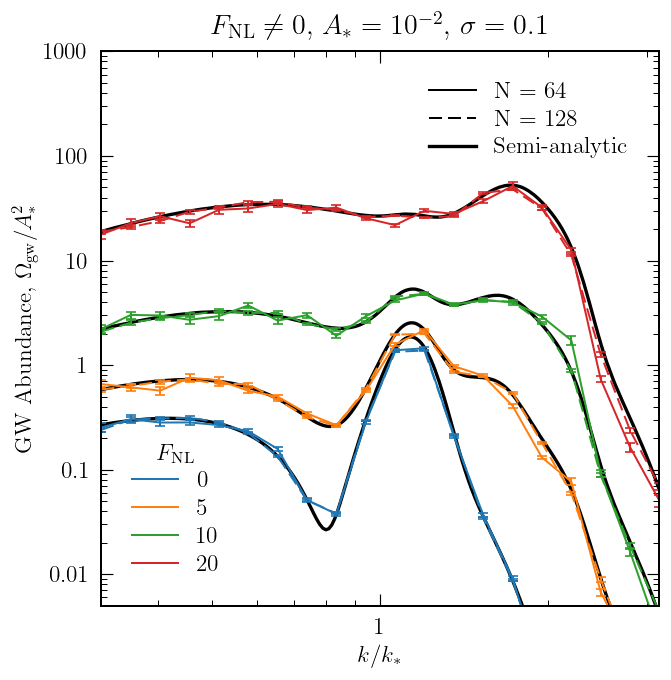

In [20]:
F_NL = [0, 5, 10., 20.]


A_star = 1e-2
k_star = 1
sigma = 0.1
Delta_zeta = flan_sigw.build_log_normal(A_star, k_star, sigma)

k = 10**torch.linspace(-1, 0.5, 20, device=device)*k_star
eps = 0.2
k_ = k_star*10**torch.arange(-2, 2, 0.01)
y = Delta_zeta(k_)
y = scipy.integrate.cumulative_trapezoid(y, torch.log(k_), initial=0)
y = torch.tensor(y)
k_bar = 3.*k_[torch.min(torch.argwhere(y/y[-1]>1- eps))]


k = 10**torch.linspace(-0.5, 0.5, 20, device=device)*k_star

for i in range(0, len(F_NL)):
    N_low = 64
    N = N_low
    O_gw = []
    sigma_O_gw = []
    
    plt.loglog(k_data, Omega_gw_nongaussian(A_star, F_NL[i], 0)/A_star**2, color = 'black', linewidth = 2)
    for kk in k:    
        k_max = np.max([k_bar, 3.*kk.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_field_k(N, L, Delta_zeta, F_NL[i], 0,  device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(kk, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='-', capsize=3)
    N_high = 2*N_low
    N = N_high
    O_gw = []
    sigma_O_gw = []
    for kk in k:    
        k_max = np.max([k_bar, 3.*kk.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_field_k(N, L, Delta_zeta, F_NL[i], 0,  device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(kk, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='--', capsize=3)

plt.title("$F_{\\rm NL}\\neq 0$, $A_* = 10^{-2}$, $\\sigma = 0.1$")
plt.yscale('log')
plt.xscale('log')
plt.ylabel('GW Abundance, $\Omega_{\\rm gw}/A_*^2$')
plt.xlabel('$k/k_*$')
plt.xlim(k.cpu()[0], k.cpu()[-1])


color_handles = [mlines.Line2D([], [], color=cmap(i), linestyle='-', label=f'{F_NL[i]:.0f}') for i in range(len(F_NL))]
first_legend = plt.legend(handles=color_handles, title='$F_{\\rm NL}$', loc='lower left')
plt.gca().add_artist(first_legend) 

style_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', label=f'N = {N_low:.0f}'),
    mlines.Line2D([], [], color='black', linestyle='--', label=f'N = {N_high:.0f}'),
    mlines.Line2D([], [], color='black', linewidth = '2', linestyle='-', label=f'Semi-analytic')
]
plt.legend(handles=style_handles, loc='upper right') 
plt.ylim(0.005, 1000)
plt.savefig('plots/nongaussian_F_NL.pdf')
plt.show()

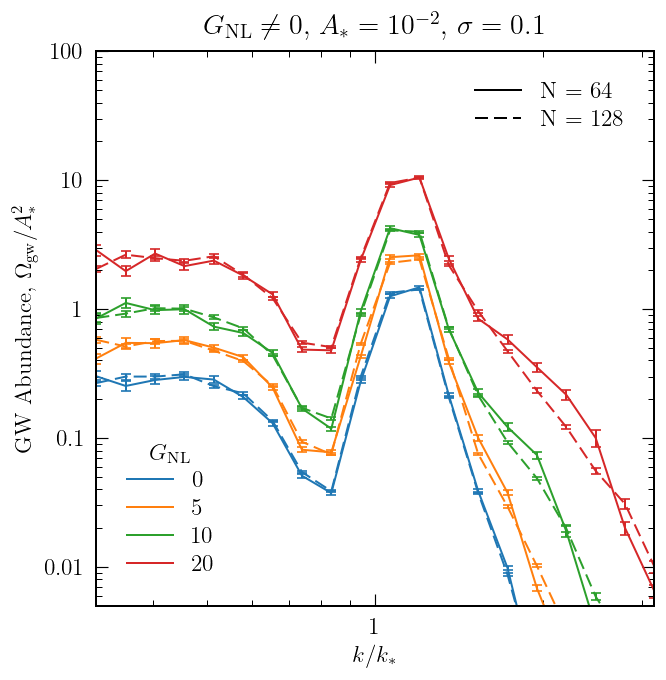

In [21]:
G_NL = [0., 5.,  10., 20.]

A_star = 1e-2
k_star = 1
sigma = 0.1
Delta_zeta = flan_sigw.build_log_normal(A_star, k_star, sigma)

k = 10**torch.linspace(-1, 0.5, 20, device=device)*k_star
eps = 0.1
k_ = k_star*10**torch.arange(-2, 2, 0.01)
y = Delta_zeta(k_)
y = scipy.integrate.cumulative_trapezoid(y, torch.log(k_), initial=0)
y = torch.tensor(y)
k_bar = 3.*k_[torch.min(torch.argwhere(y/y[-1]>1- eps))]


k = 10**torch.linspace(-0.5, 0.5, 20, device=device)*k_star

for i in range(0, len(G_NL)):  
    #plt.loglog(k_data, Omega_gw_nongaussian(A_star, 0, G_NL[i])/A_star**2, color = 'black', linewidth = 2)
    
    N_low = 64
    N = N_low
    O_gw = []
    sigma_O_gw = []
    for kk in k:    
        k_max = np.max([k_bar, 3.*kk.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_field_k(N, L, Delta_zeta, 0, G_NL[i],  device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(kk, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='-', capsize=3)
    
    N_high = 2*N_low
    N = N_high
    O_gw = []
    sigma_O_gw = []
    for kk in k:    
        k_max = np.max([k_bar, 3.*kk.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_field_k(N, L, Delta_zeta, 0, G_NL[i],  device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(kk, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='--', capsize=3)

plt.title("$G_{\\rm NL}\\neq 0$, $A_* = 10^{-2}$, $\\sigma = 0.1$")
plt.yscale('log')
plt.xscale('log')
plt.ylabel('GW Abundance, $\Omega_{\\rm gw}/A_*^2$')
plt.xlabel('$k/k_*$')
plt.xlim(k.cpu()[0], k.cpu()[-1])


color_handles = [mlines.Line2D([], [], color=cmap(i), linestyle='-', label=f'{G_NL[i]:.0f}') for i in range(len(G_NL))]
first_legend = plt.legend(handles=color_handles, title='$G_{\\rm NL}$', loc='lower left')
plt.gca().add_artist(first_legend) 

style_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', label=f'N = {N_low:.0f}'),
    mlines.Line2D([], [], color='black', linestyle='--', label=f'N = {N_high:.0f}')
]
plt.legend(handles=style_handles, loc='upper right') 
plt.ylim(0.005, 100)
plt.savefig('plots/nongaussian_G_NL.pdf')
plt.show()

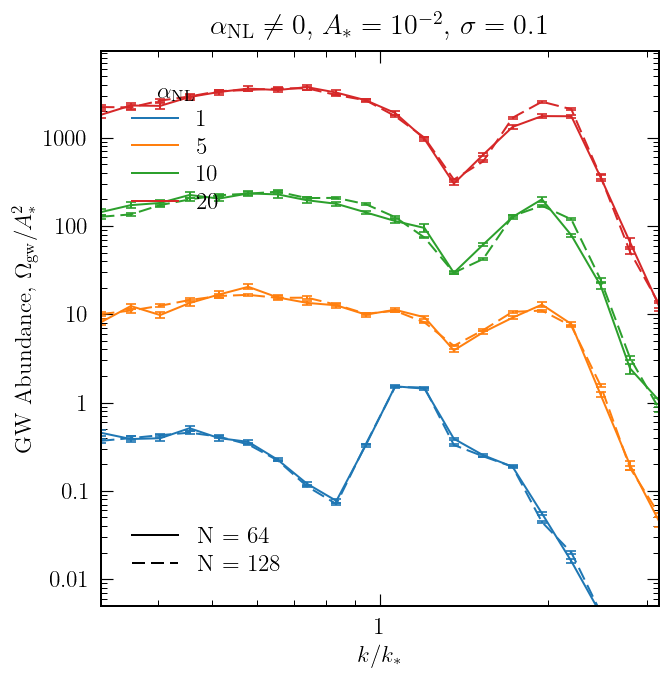

In [22]:
alpha_NL = [1., 5.,  10., 20.]
cmap = plt.get_cmap('tab10')
for i in range(0, len(alpha_NL)):
    N_low = 64
    N = N_low
    O_gw = []
    sigma_O_gw = []
    for k_ in k:    
        k_max = np.max([k_bar, 3.*k_.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_nonlocal_field_k(N, L, Delta_zeta, k_star, alpha_NL[i], 0, device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(k_, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='-', capsize=3)
    N_high = 2*N_low
    N = N_high
    O_gw = []
    sigma_O_gw = []
    for k_ in k:    
        k_max = np.max([k_bar, 3.*k_.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_nonlocal_field_k(N, L, Delta_zeta, k_star, alpha_NL[i], 0, device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(k_, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='--', capsize=3)

plt.title("$\\alpha_{\\rm NL}\\neq 0$, $A_* = 10^{-2}$, $\\sigma = 0.1$")
plt.yscale('log')
plt.xscale('log')
plt.ylabel('GW Abundance, $\Omega_{\\rm gw}/A_*^2$')
plt.xlabel('$k/k_*$')
plt.xlim(k.cpu()[0], k.cpu()[-1])


color_handles = [mlines.Line2D([], [], color=cmap(i), linestyle='-', label=f'{alpha_NL[i]:.0f}') for i in range(len(alpha_NL))]
first_legend = plt.legend(handles=color_handles, title='$\\alpha_{\\rm NL}$', loc='upper left')
plt.gca().add_artist(first_legend) 

style_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', label=f'N = {N_low:.0f}'),
    mlines.Line2D([], [], color='black', linestyle='--', label=f'N = {N_high:.0f}')
]
plt.legend(handles=style_handles, loc='lower left') 
plt.ylim(0.005, )
plt.savefig('plots/nongaussian_alpha_NL.pdf')
plt.show()

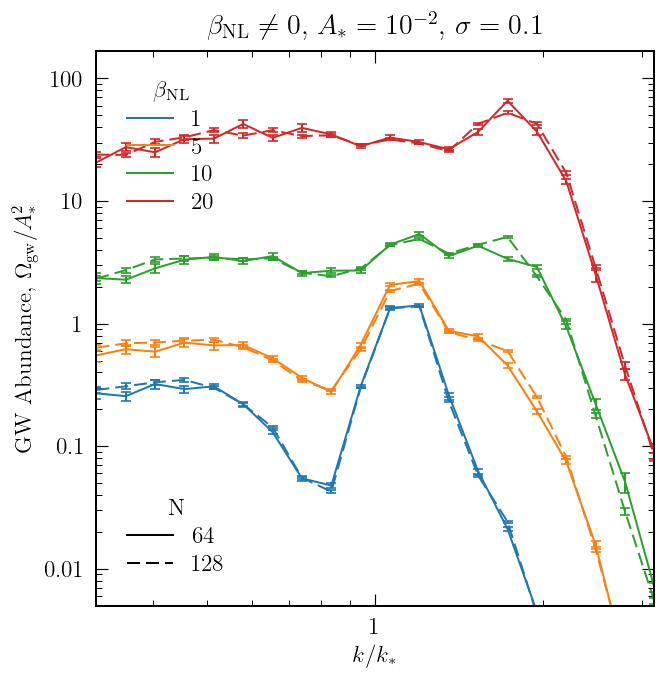

In [23]:
beta_NL = [1., 5.,  10., 20.]
for i in range(0, len(beta_NL)):
    N_low = 64
    N = N_low
    O_gw = []
    sigma_O_gw = []
    for k_ in k:    
        k_max = np.max([k_bar, 3.*k_.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_nonlocal_field_k(N, L, Delta_zeta, k_star, 0, beta_NL[i], device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(k_, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='-', capsize=3)
    N_high = 2*N_low
    N = N_high
    O_gw = []
    sigma_O_gw = []
    for k_ in k:    
        k_max = np.max([k_bar, 3.*k_.cpu()])
        L = N*np.pi/k_max
        Phi_i_k  = (2./3.)*flan_sigw.generate_nongaussian_nonlocal_field_k(N, L, Delta_zeta, k_star, 0, beta_NL[i], device = device)
        O_gw_, sigma_O_gw_ = Omega_gw_1(k_, Phi_i_k, L, N_modes)
        O_gw.append(O_gw_)
        sigma_O_gw.append(sigma_O_gw_)

    O_gw = torch.stack(O_gw)
    sigma_O_gw = torch.stack(sigma_O_gw)
    
    plt.errorbar(k.cpu(), O_gw.cpu()/A_star**2, yerr=sigma_O_gw.cpu()/A_star**2, 
                 color=cmap(i), linestyle='--', capsize=3)

plt.title("$\\beta_{\\rm NL}\\neq 0$, $A_* = 10^{-2}$, $\\sigma = 0.1$")
plt.yscale('log')
plt.xscale('log')
plt.ylabel('GW Abundance, $\Omega_{\\rm gw}/A_*^2$')
plt.xlabel('$k/k_*$')
plt.xlim(k.cpu()[0], k.cpu()[-1])


color_handles = [mlines.Line2D([], [], color=cmap(i), linestyle='-', label=f'{beta_NL[i]:.0f}') for i in range(len(beta_NL))]
first_legend = plt.legend(handles=color_handles, title='$\\beta_{\\rm NL}$', loc='upper left')
plt.gca().add_artist(first_legend) 

style_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', label=f'{N_low:.0f}'),
    mlines.Line2D([], [], color='black', linestyle='--', label=f'{N_high:.0f}')
]
plt.legend(handles=style_handles, title='N', loc='lower left') 
plt.ylim(0.005, )

plt.savefig('plots/nonngaussian_beta_NL.pdf')
plt.show()